In [1]:
import os
import time
from pathlib import Path
import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from scipy.ndimage import convolve
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from torchinfo import summary

DATA_DIR = Path.cwd().parent / "data" / "hyperspectral_oil_spill"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

train_files = sorted([f for f in DATA_DIR.glob("*.mat") if f.stem not in ["GM01", "GM02", "GM03"]])
test_files = sorted([f for f in DATA_DIR.glob("*.mat") if f.stem in ["GM01", "GM02"]])
all_files = sorted(list(DATA_DIR.glob("*.mat")))

/home/ycwang/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
def evaluate_band_retention_dynamic(file_list):
    water_vapor_bands = set(list(range(104, 114)) + list(range(148, 168)) + list(range(221, 224)))
    sample_img = sio.loadmat(file_list[0])["img"]
    valid_bands = [b for b in range(sample_img.shape[2]) if b not in water_vapor_bands]
    mask = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], dtype=float)
    all_file_scores = []
    
    for file_path in tqdm(file_list, desc="Evaluating Spectral Noise"):
        img = sio.loadmat(file_path)["img"]
        H, W, _ = img.shape
        scores = []
        for b in valid_bands:
            band_data = img[:, :, b].astype(float)
            p_low, p_high = np.percentile(band_data, (1, 99))
            band_norm = np.clip((band_data - p_low) / (p_high - p_low + 1e-8), 0, 1)
            noise = np.abs(convolve(band_norm, mask)[1:-1, 1:-1]).sum()
            sigma_n = noise * np.sqrt(np.pi / 2) / (6 * (H - 2) * (W - 2))
            scores.append(sigma_n)
        all_file_scores.append(scores)
        
    avg_sigma = np.mean(all_file_scores, axis=0)
    adaptive_thresh = np.mean(avg_sigma)
    ultra_clean = [valid_bands[i] for i, sigma in enumerate(avg_sigma) if sigma < adaptive_thresh]
    return np.sort(ultra_clean).tolist()

CLEAN_BANDS = evaluate_band_retention_dynamic(all_files)
print(f"Retained {len(CLEAN_BANDS)} clean bands.")

Evaluating Spectral Noise: 100%|██████████| 18/18 [01:49<00:00,  6.08s/it]

Retained 138 clean bands.


In [3]:
class OilSpillCNN(nn.Module):
    def __init__(self, in_bands, mlp_dim=64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_bands, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )
        self.mlp = nn.Sequential(
            nn.Linear(64, mlp_dim),
            nn.ReLU(inplace=True),
            nn.Linear(mlp_dim, mlp_dim)
        )
        self.classifier = nn.Linear(mlp_dim, 1)

    def forward(self, x, pretrain=False):
        x = self.features(x)
        x = self.mlp(x)
        if pretrain:
            return x
        return self.classifier(x)

model = OilSpillCNN(in_bands=len(CLEAN_BANDS)).to(device)

In [4]:
# Load the weights that performed best on GM03
weights_path = f"best_finetuned_cnn_{len(CLEAN_BANDS)}_cosine.pth"
model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
model.eval()
print(f"Successfully loaded best GM03 validation weights from: {weights_path}")

# Calculate Parameters and MACs (Multiply-Accumulate Operations ~ FLOPS)
input_shape = (1, len(CLEAN_BANDS), 11, 11)
model_stats = summary(model, input_size=input_shape, verbose=0)
TOTAL_PARAMS = model_stats.total_params
# 1 MAC is generally considered equivalent to 2 FLOPS (one multiply, one add)
TOTAL_MACS = model_stats.total_mult_adds 

print(f"\n--- Model Hardware Complexity (Per 11x11 Patch) ---")
print(f"Total Parameters: {TOTAL_PARAMS:,}")
print(f"Total MACs:       {TOTAL_MACS:,} (~{TOTAL_MACS * 2:,} FLOPS)")

Successfully loaded best GM03 validation weights from: best_finetuned_cnn_138_cosine.pth

--- Model Hardware Complexity (Per 11x11 Patch) ---
Total Parameters: 112,833
Total MACs:       7,325,889 (~14,651,778 FLOPS)


Calibrating on Train Scenes: 100%|██████████| 16/16 [42:20<00:00, 158.79s/it] 


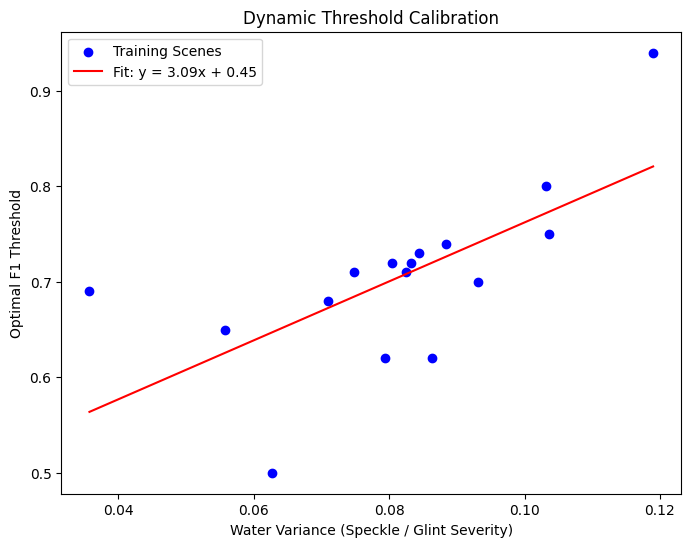

=> Fitted Threshold Equation: Threshold = 3.0873 * Variance + 0.4535


In [5]:
def calibrate_threshold(model, files, clean_bands, patch_size=11):
    variances = []
    optimal_thresholds = []
    pad = patch_size // 2
    
    for file_path in tqdm(files, desc="Calibrating on Train Scenes"):
        mat = sio.loadmat(file_path)
        img, gt = mat["img"], mat["map"]
        
        img_clean = img[:, :, clean_bands].astype(np.float32)
        for b in range(img_clean.shape[2]):
            band = img_clean[:, :, b]
            p_low, p_high = np.percentile(band, (1, 99))
            img_clean[:, :, b] = np.clip((band - p_low) / (p_high - p_low + 1e-8), 0, 1)
            
        intensity_map = np.mean(img_clean, axis=2)
        water_pixels = intensity_map[gt == 0]
        if len(water_pixels) == 0:
            continue
            
        variance = np.std(water_pixels)
        img_padded = np.pad(img_clean, ((pad, pad), (pad, pad), (0, 0)), mode='symmetric')
        H, W = gt.shape
        valid_coords = [(r, c) for r in range(H) for c in range(W) if gt[r, c] >= 0]
        
        all_probs = []
        all_targets = []
        batch_size = 4096
        
        with torch.inference_mode():
            for i in range(0, len(valid_coords), batch_size):
                batch_coords = valid_coords[i:i+batch_size]
                batch = [img_padded[r:r+patch_size, c:c+patch_size, :].transpose(2, 0, 1) for r, c in batch_coords]
                batch_tensor = torch.tensor(np.array(batch), dtype=torch.float32).to(device)
                probs = torch.sigmoid(model(batch_tensor).squeeze(1)).cpu().numpy()
                all_probs.extend(probs)
                all_targets.extend([gt[r, c] for r, c in batch_coords])
                
        best_f1, best_thresh = 0, 0.50
        for t in np.linspace(0.50, 0.99, 50):
            temp_preds = (np.array(all_probs) > t).astype(int)
            score = f1_score(all_targets, temp_preds, zero_division=0)
            if score > best_f1:
                best_f1, best_thresh = score, t
                
        variances.append(variance)
        optimal_thresholds.append(best_thresh)
        
    m, b = np.polyfit(variances, optimal_thresholds, 1)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(variances, optimal_thresholds, color='blue', label='Training Scenes')
    x_line = np.linspace(min(variances), max(variances), 100)
    plt.plot(x_line, m * x_line + b, color='red', label=f'Fit: y = {m:.2f}x + {b:.2f}')
    plt.xlabel('Water Variance (Speckle / Glint Severity)')
    plt.ylabel('Optimal F1 Threshold')
    plt.title('Dynamic Threshold Calibration')
    plt.legend()
    plt.show()
    
    print(f"=> Fitted Threshold Equation: Threshold = {m:.4f} * Variance + {b:.4f}")
    return m, b

# Include GM03 (Validation) in the calibration curve
calibration_files = [f for f in all_files if f.stem not in ["GM01", "GM02"]]
m, b = calibrate_threshold(model, calibration_files, CLEAN_BANDS)

In [6]:
def evaluate_and_plot_test_scene(model, file_path, clean_bands, device, m, b, mode="leaked", patch_size=11):
    mat = sio.loadmat(file_path)
    img, gt = mat["img"], mat["map"]
    
    # 1. Image preparation & RGB formatting
    rgb_raw = img[:, :, [29, 19, 9]].astype(np.float32)
    rgb_clean = np.where(rgb_raw < 0, 0, rgb_raw)
    rgb_img = np.zeros_like(rgb_clean)
    for c in range(3):
        channel = rgb_clean[:, :, c]
        p_low, p_high = np.percentile(channel[channel > 0], (1, 99))
        rgb_img[:, :, c] = np.clip((channel - p_low) / (p_high - p_low + 1e-8), 0, 1)
        
    img_clean = img[:, :, clean_bands].astype(np.float32)
    for band_idx in range(img_clean.shape[2]):
        band = img_clean[:, :, band_idx]
        p_low, p_high = np.percentile(band, (1, 99))
        img_clean[:, :, band_idx] = np.clip((band - p_low) / (p_high - p_low + 1e-8), 0, 1)
        
    intensity_map = np.mean(img_clean, axis=2)
    
    # --- CALCULATE BOTH VARIANCES FOR COMPARISON LOGGING ---
    # 1. True Leaked Variance
    water_pixels = intensity_map[gt == 0]
    true_variance = np.std(water_pixels) if len(water_pixels) > 0 else 0.0
    
    # 2. Robust Unsupervised Variance (MAD)
    scene_median = np.median(intensity_map)
    scene_mad = np.median(np.abs(intensity_map - scene_median))
    robust_std = 1.4826 * scene_mad
    
    # --- SELECT WHICH TO USE BASED ON MODE ---
    if mode == "leaked":
        scene_variance = true_variance
        mode_title = "LEAKED (Ground Truth Water Variance)"
    elif mode == "unsupervised":
        scene_variance = robust_std
        mode_title = "UNSUPERVISED (Robust MAD Variance)"
    else:
        raise ValueError("Mode must be 'leaked' or 'unsupervised'")
    
    predicted_threshold = m * scene_variance + b
    predicted_threshold = np.clip(predicted_threshold, 0.50, 0.99)
        
    pad = patch_size // 2
    img_padded = np.pad(img_clean, ((pad, pad), (pad, pad), (0, 0)), mode='symmetric')
    H, W = gt.shape
    valid_coords = [(r, c) for r in range(H) for c in range(W) if gt[r, c] >= 0]
    
    batch_size = 512 
    raw_prob_map = np.zeros((H, W))
    
    # 2. Timing the Core Inference
    start_time = time.time()
    
    with torch.inference_mode():
        for i in tqdm(range(0, len(valid_coords), batch_size), desc=f"Inferring {file_path.stem} ({mode})"):
            batch_coords = valid_coords[i:i+batch_size]
            batch = [img_padded[r:r+patch_size, c:c+patch_size, :].transpose(2, 0, 1) for r, c in batch_coords]
            batch_tensor = torch.tensor(np.array(batch), dtype=torch.float32).to(device)
            
            probs = torch.sigmoid(model(batch_tensor).squeeze(1)).cpu().numpy()
            for (r, c), prob in zip(batch_coords, probs):
                raw_prob_map[r, c] = prob
                
    end_time = time.time()
    eval_time_total = end_time - start_time
    num_pixels = len(valid_coords)
    eval_time_avg = eval_time_total / num_pixels if num_pixels > 0 else 0

    # 3. Apply Threshold and Calculate Metrics
    all_probs = [raw_prob_map[r, c] for r, c in valid_coords]
    all_targets = [gt[r, c] for r, c in valid_coords]
    
    valid_mask = (gt >= 0)
    predictions = (raw_prob_map > predicted_threshold).astype(int) * valid_mask
    preds_binary = (np.array(all_probs) > predicted_threshold).astype(int)

    auc = roc_auc_score(all_targets, all_probs)
    precision = precision_score(all_targets, preds_binary, zero_division=0)
    recall = recall_score(all_targets, preds_binary, zero_division=0)
    f1 = f1_score(all_targets, preds_binary, zero_division=0)
    
    # 4. Print Exact Requested Metrics
    print(f"\n{'='*60}")
    print(f"TEST EVALUATION: {file_path.stem} | {mode_title}")
    print(f"{'='*60}")
    print(f"  -> True Water Variance (Leaked): {true_variance:.4f}")
    print(f"  -> Robust Water Variance (MAD):  {robust_std:.4f}")
    print(f"Predicted Dynamic Threshold : {predicted_threshold:.4f} (Used {scene_variance:.4f})")
    print(f"ROC-AUC                     : {auc:.4f}")
    print(f"Precision                   : {precision:.4f}")
    print(f"Recall                      : {recall:.4f}")
    print(f"F1 Score                    : {f1:.4f}")
    print(f"-"*60)
    print(f"Hardware & Complexity")
    print(f"Parameters                  : {TOTAL_PARAMS:,}")
    print(f"MACs (per patch)            : {TOTAL_MACS:,}")
    print(f"FLOPS (approx per patch)    : {TOTAL_MACS * 2:,}")
    print(f"-"*60)
    print(f"Timing & Efficiency")
    print(f"Total Evaluation Time       : {eval_time_total:.2f} seconds")
    print(f"Total Pixels Evaluated      : {num_pixels:,} pixels")
    print(f"Average Time per Pixel      : {eval_time_avg:.6f} seconds")
    print(f"{'='*60}\n")

    # 5. Plot the Maps
    fig, axs = plt.subplots(1, 3, figsize=(18, 8))
    axs[0].imshow(rgb_img)
    axs[0].set_title(f"False-Color RGB ({file_path.stem})")
    axs[1].imshow(gt == 1, cmap='magma')
    axs[1].set_title("Ground Truth Mask")
    axs[2].imshow(predictions, cmap='magma')
    axs[2].set_title(f"Prediction (Thresh {predicted_threshold:.2f})")
    for ax in axs: 
        ax.axis("off")
    plt.tight_layout()
    plt.show()


##################################################
 SCENARIO 1: GROUND TRUTH LEAKED EVALUATION
##################################################


Inferring GM01 (leaked): 100%|██████████| 1661/1661 [01:49<00:00, 15.17it/s]



TEST EVALUATION: GM01 | LEAKED (Ground Truth Water Variance)
  -> True Water Variance (Leaked): 0.1190
  -> Robust Water Variance (MAD):  0.1017
Predicted Dynamic Threshold : 0.8208 (Used 0.1190)
ROC-AUC                     : 0.9890
Precision                   : 0.5607
Recall                      : 0.8691
F1 Score                    : 0.6817
------------------------------------------------------------
Hardware & Complexity
Parameters                  : 112,833
MACs (per patch)            : 7,325,889
FLOPS (approx per patch)    : 14,651,778
------------------------------------------------------------
Timing & Efficiency
Total Evaluation Time       : 109.50 seconds
Total Pixels Evaluated      : 850,212 pixels
Average Time per Pixel      : 0.000129 seconds



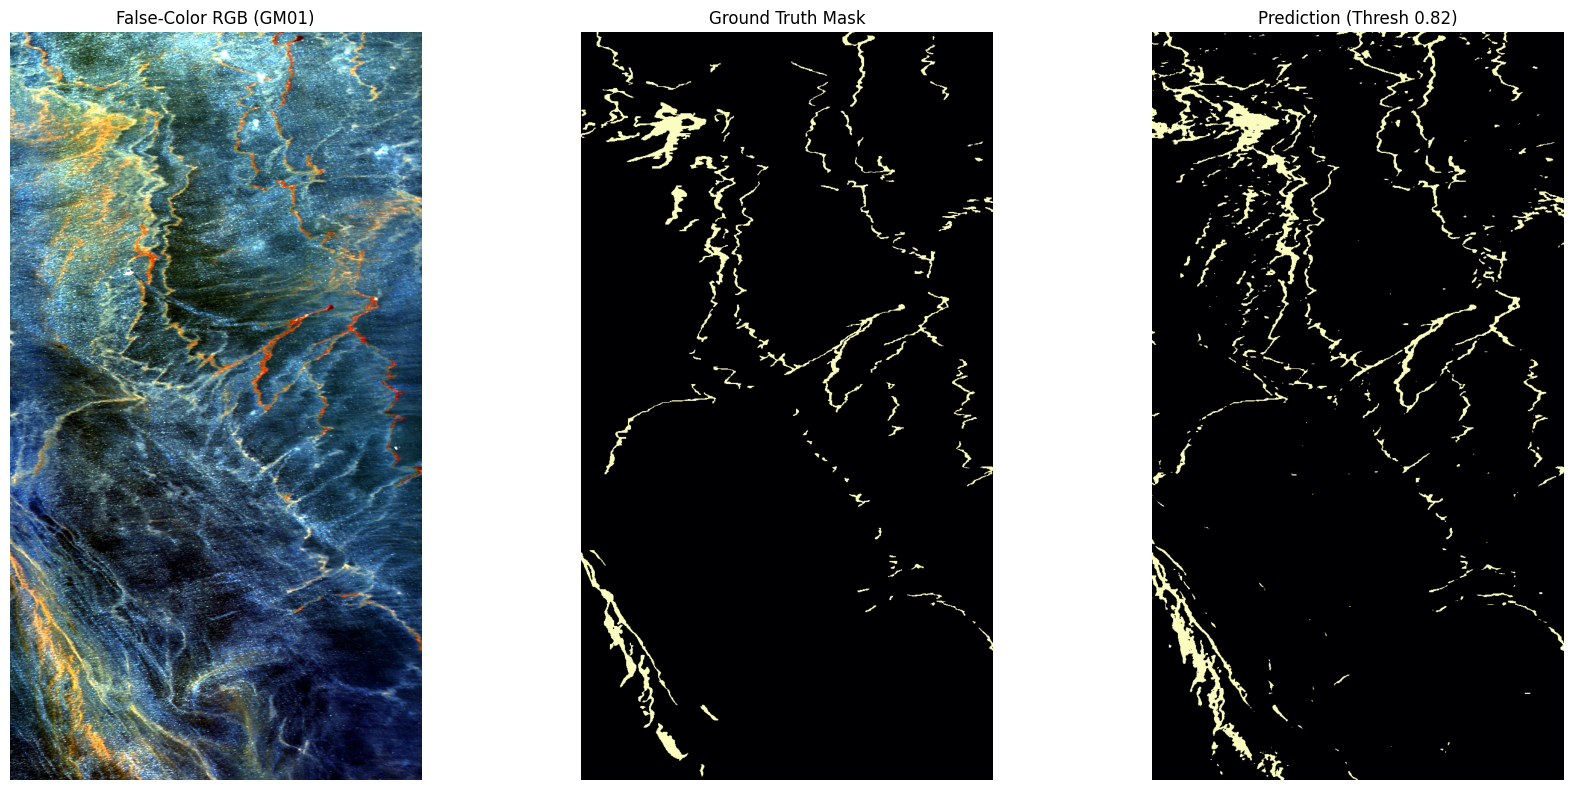

Inferring GM02 (leaked): 100%|██████████| 2439/2439 [03:13<00:00, 12.62it/s]



TEST EVALUATION: GM02 | LEAKED (Ground Truth Water Variance)
  -> True Water Variance (Leaked): 0.2043
  -> Robust Water Variance (MAD):  0.2168
Predicted Dynamic Threshold : 0.9900 (Used 0.2043)
ROC-AUC                     : 0.9772
Precision                   : 0.7676
Recall                      : 0.5221
F1 Score                    : 0.6215
------------------------------------------------------------
Hardware & Complexity
Parameters                  : 112,833
MACs (per patch)            : 7,325,889
FLOPS (approx per patch)    : 14,651,778
------------------------------------------------------------
Timing & Efficiency
Total Evaluation Time       : 193.21 seconds
Total Pixels Evaluated      : 1,248,414 pixels
Average Time per Pixel      : 0.000155 seconds



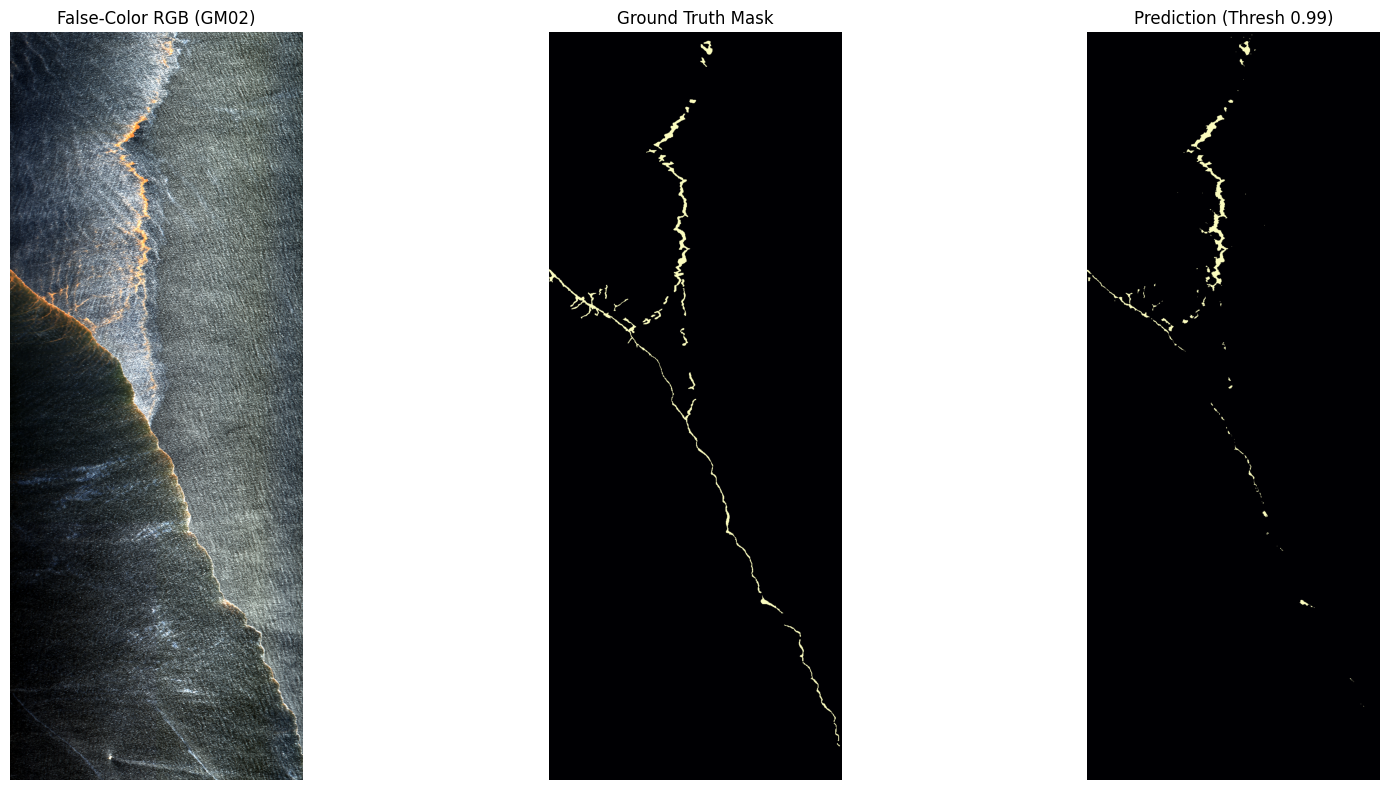

In [7]:
print("\n" + "#"*50)
print(" SCENARIO 1: GROUND TRUTH LEAKED EVALUATION")
print("#"*50)
for test_file in test_files:
    evaluate_and_plot_test_scene(model, test_file, CLEAN_BANDS, device, m, b, mode="leaked")


##################################################
 SCENARIO 2: REAL-WORLD UNSUPERVISED EVALUATION
##################################################


Inferring GM01 (unsupervised): 100%|██████████| 1661/1661 [01:32<00:00, 17.88it/s]



TEST EVALUATION: GM01 | UNSUPERVISED (Robust MAD Variance)
  -> True Water Variance (Leaked): 0.1190
  -> Robust Water Variance (MAD):  0.1017
Predicted Dynamic Threshold : 0.7675 (Used 0.1017)
ROC-AUC                     : 0.9890
Precision                   : 0.5257
Recall                      : 0.8958
F1 Score                    : 0.6625
------------------------------------------------------------
Hardware & Complexity
Parameters                  : 112,833
MACs (per patch)            : 7,325,889
FLOPS (approx per patch)    : 14,651,778
------------------------------------------------------------
Timing & Efficiency
Total Evaluation Time       : 92.91 seconds
Total Pixels Evaluated      : 850,212 pixels
Average Time per Pixel      : 0.000109 seconds



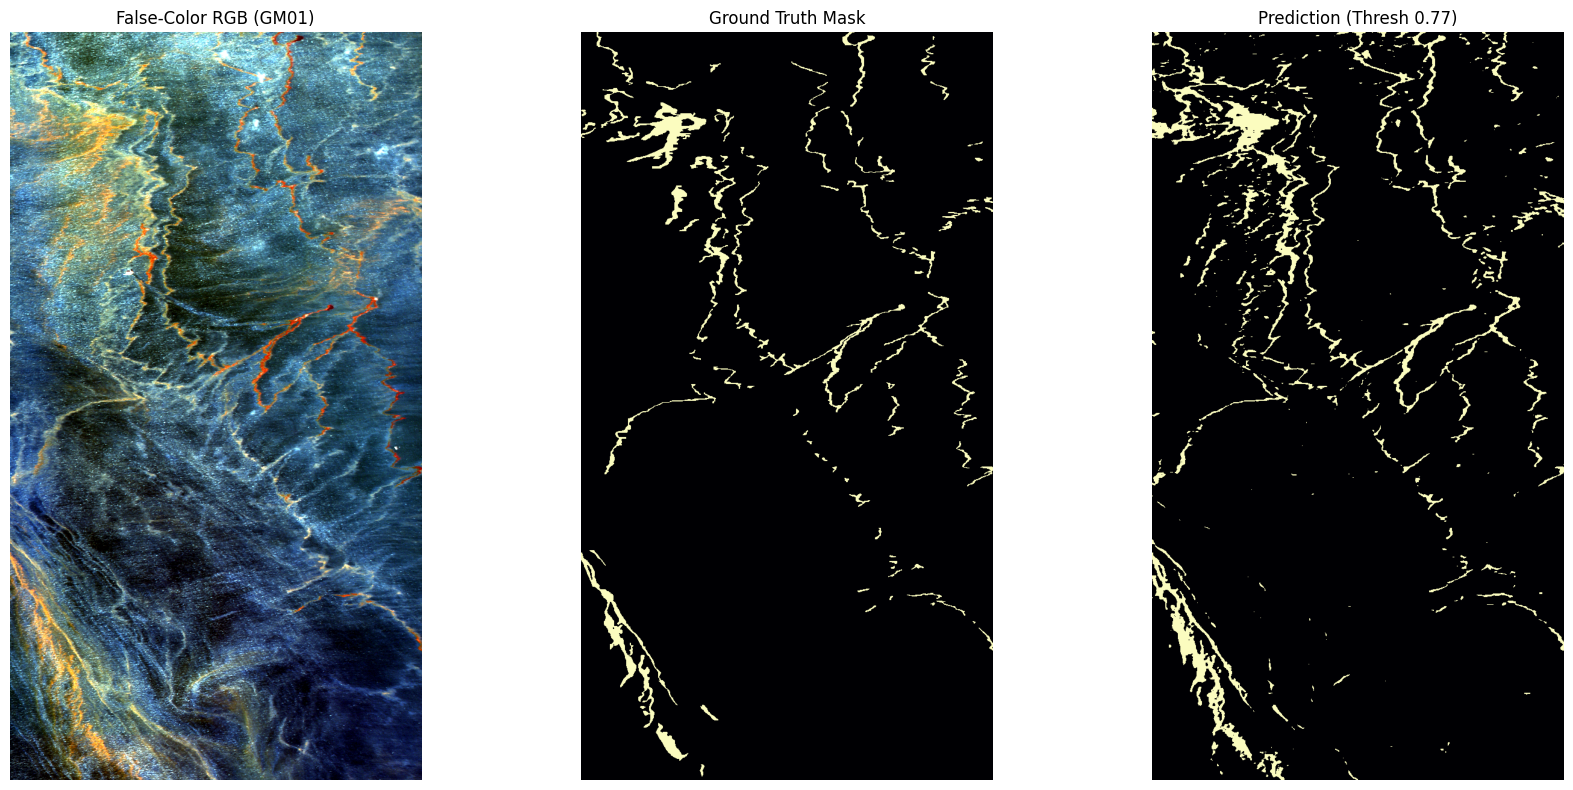

Inferring GM02 (unsupervised): 100%|██████████| 2439/2439 [02:49<00:00, 14.39it/s]



TEST EVALUATION: GM02 | UNSUPERVISED (Robust MAD Variance)
  -> True Water Variance (Leaked): 0.2043
  -> Robust Water Variance (MAD):  0.2168
Predicted Dynamic Threshold : 0.9900 (Used 0.2168)
ROC-AUC                     : 0.9772
Precision                   : 0.7676
Recall                      : 0.5221
F1 Score                    : 0.6215
------------------------------------------------------------
Hardware & Complexity
Parameters                  : 112,833
MACs (per patch)            : 7,325,889
FLOPS (approx per patch)    : 14,651,778
------------------------------------------------------------
Timing & Efficiency
Total Evaluation Time       : 169.56 seconds
Total Pixels Evaluated      : 1,248,414 pixels
Average Time per Pixel      : 0.000136 seconds



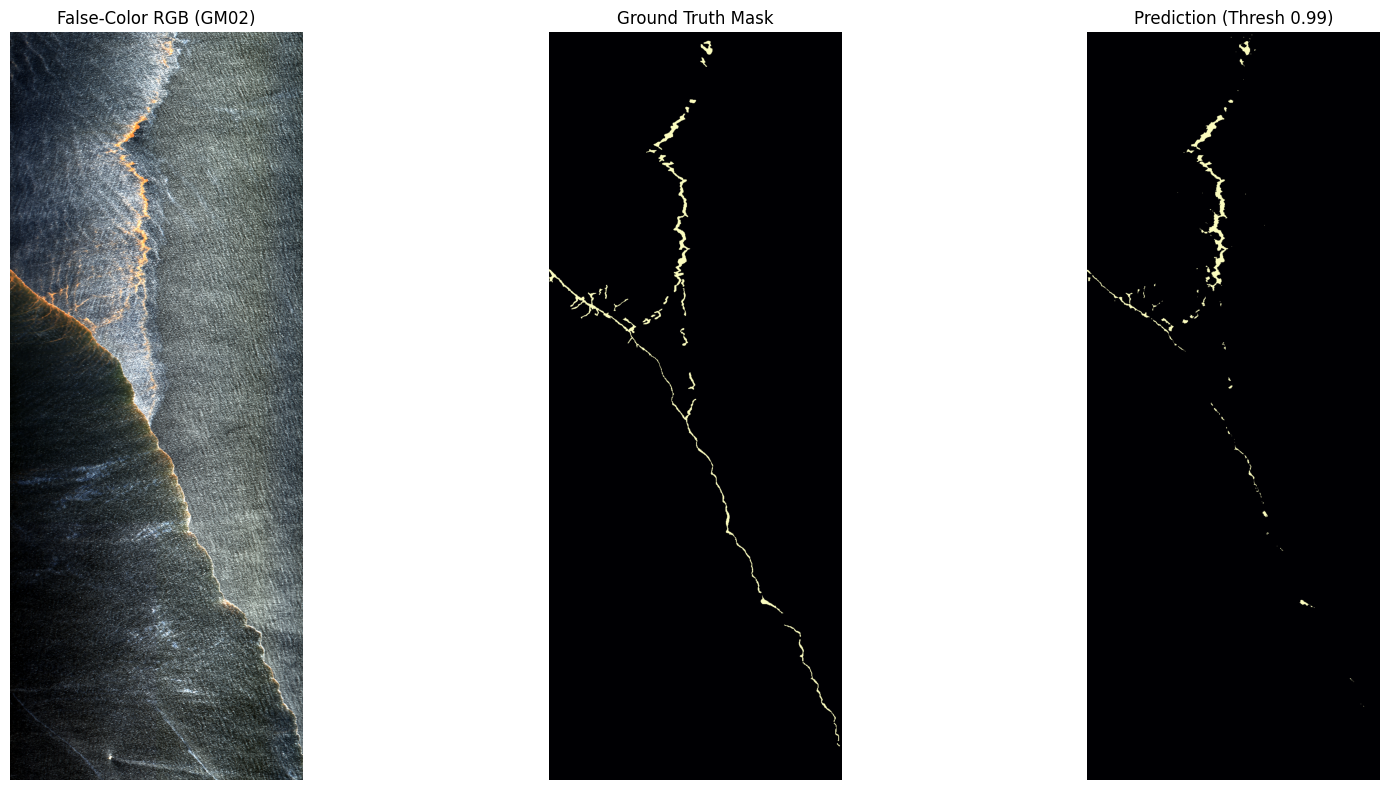

In [8]:
print("\n" + "#"*50)
print(" SCENARIO 2: REAL-WORLD UNSUPERVISED EVALUATION")
print("#"*50)
for test_file in test_files:
    evaluate_and_plot_test_scene(model, test_file, CLEAN_BANDS, device, m, b, mode="unsupervised")

In [ ]:
matplotlib.use('Agg')

mat_files = list(DATA_DIR.glob("*.mat"))

# 1. Exact Band Selection used in Training (Scaling BEFORE Noise Calculation)
def get_adaptive_clean_bands(file_list):
    print("Dynamically calculating noise variance across ALL files with (1, 99) scaling...")
    water_vapor_bands = set(list(range(104, 114)) + list(range(148, 168)) + list(range(221, 224)))
    sample_img = sio.loadmat(file_list[0])["img"]
    total_raw_bands = sample_img.shape[2]
    
    valid_bands = [b for b in range(total_raw_bands) if b not in water_vapor_bands]
    mask = np.array([[1, -2,  1], [-2, 4, -2], [1, -2,  1]], dtype=float)
    all_file_scores = []
    
    for file_path in tqdm(file_list, desc="Evaluating Spectral Noise"):
        img = sio.loadmat(file_path)["img"]
        H, W, _ = img.shape
        scores = []
        for b in valid_bands:
            band_data = img[:, :, b].astype(float)
            
            # CRITICAL: Scale before noise evaluation to prevent glint from skewing variance
            p_low, p_high = np.percentile(band_data, (1, 99))
            band_norm = np.clip((band_data - p_low) / (p_high - p_low + 1e-8), 0, 1)
            
            # Calculate noise on the normalized data
            noise = np.abs(convolve(band_norm, mask)[1:-1, 1:-1]).sum()
            sigma_n = noise * np.sqrt(np.pi / 2) / (6 * (H - 2) * (W - 2))
            scores.append(sigma_n)
        all_file_scores.append(scores)
        
    avg_sigma_per_band = np.mean(all_file_scores, axis=0)
    adaptive_threshold = np.mean(avg_sigma_per_band)
    
    ultra_clean_bands = [valid_bands[i] for i, sigma in enumerate(avg_sigma_per_band) if sigma < adaptive_threshold]
    print(f"Adaptive Noise Threshold: {adaptive_threshold:.4f}")
    print(f"Retained {len(ultra_clean_bands)} clean bands.")
    return np.sort(ultra_clean_bands).tolist()

CLEAN_BANDS = get_adaptive_clean_bands(mat_files)

# 2. Analyze the Water in every scene using the exact CNN preprocessing
results = []

print("\nScanning scenes for Sun Glint and Wind Wake...")
for file_path in tqdm(mat_files, desc="Extracting Metrics"):
    mat = sio.loadmat(file_path)
    img, gt = mat["img"], mat["map"]
    
    # Normalize exactly how the CNN will see it
    img_clean = img[:, :, CLEAN_BANDS].astype(np.float32)
    for b in range(img_clean.shape[2]):
        band = img_clean[:, :, b]
        p_low, p_high = np.percentile(band, (1, 99))
        img_clean[:, :, b] = np.clip((band - p_low) / (p_high - p_low + 1e-8), 0, 1)
    
    # Calculate average intensity across all clean bands to create a 2D grayscale map
    intensity_map = np.mean(img_clean, axis=2)
    
    # Isolate ONLY the known water
    water_mask = (gt == 0)
    water_pixels = intensity_map[water_mask]
    
    if len(water_pixels) == 0:
        continue
        
    # Glint metrics
    mean_brightness = np.mean(water_pixels)
    speckle_variance = np.std(water_pixels)
    extreme_glint = np.percentile(water_pixels, 98) # How bright is the top 2% of water?
    
    results.append({
        'name': file_path.stem,
        'mean': mean_brightness,
        'variance': speckle_variance,
        'glint_peak': extreme_glint,
        'intensity_map': intensity_map,
        'water_mask': water_mask
    })

# 3. Sort by Variance (highest speckle/glint first)
results.sort(key=lambda x: x['variance'], reverse=True)

print("\n--- WATER TEXTURE ANALYSIS (Sorted by Speckle/Glint Severity) ---")
print(f"{'Scene':<10} | {'Mean Brightness':<18} | {'Variance (Speckle)':<18} | {'98th Pct (Peak Glint)':<18}")
print("-" * 75)
for res in results:
    marker = " <--- (Testing Scene)" if res['name'] in ["GM01", "GM02"] else ""
    print(f"{res['name']:<10} | {res['mean']:<18.4f} | {res['variance']:<18.4f} | {res['glint_peak']:<18.4f}{marker}")

# 4. Generate Visual Heatmaps for the Top 3 Glintiest Training Scenes
print("\nGenerating heatmaps for the 3 glintiest training scenes...")
top_train_scenes = [r for r in results][:3]

for res in top_train_scenes:
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    
    water_only_display = res['intensity_map'].copy()
    water_only_display[~res['water_mask']] = 0 
    
    axs[0].imshow(water_only_display, cmap='gray')
    axs[0].set_title(f"{res['name']} Raw Water Intensity")
    
    axs[1].imshow(water_only_display, cmap='magma', vmin=0, vmax=res['glint_peak'])
    axs[1].set_title(f"{res['name']} Glint Heatmap")
    
    for ax in axs: ax.axis('off')
    plt.tight_layout()
    
    out_name = f"glint_analysis_{res['name']}.png"
    plt.savefig(out_name, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved {out_name}")

Dynamically calculating noise variance across ALL files with (1, 99) scaling...


Evaluating Spectral Noise: 100%|██████████| 18/18 [01:49<00:00,  6.08s/it]


Adaptive Noise Threshold: 0.0525
Retained 138 clean bands.

Scanning scenes for Sun Glint and Wind Wake...


Extracting Metrics: 100%|██████████| 18/18 [01:12<00:00,  4.03s/it]



--- WATER TEXTURE ANALYSIS (Sorted by Speckle/Glint Severity) ---
Scene      | Mean Brightness    | Variance (Speckle) | 98th Pct (Peak Glint)
---------------------------------------------------------------------------
GM02       | 0.2968             | 0.2043             | 0.8096             <--- (Testing Scene)
GM03       | 0.1908             | 0.1190             | 0.5118            
GM01       | 0.1962             | 0.1190             | 0.5228             <--- (Testing Scene)
GM06       | 0.1795             | 0.1036             | 0.4451            
GM04       | 0.1608             | 0.1031             | 0.4380            
GM09       | 0.3176             | 0.0932             | 0.5113            
GM12       | 0.1573             | 0.0883             | 0.3911            
GM07       | 0.2390             | 0.0863             | 0.4335            
GM15       | 0.2298             | 0.0844             | 0.4267            
GM14       | 0.3012             | 0.0832             | 0.4778           